In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset load 

In [ ]:
dataset = load_dataset("fancyzhx/ag_news")

df = pd.DataFrame(dataset["train"])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

c:\Users\user\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--fancyzhx--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [33]:
df

,text,label,text_length
0,Wall St. Bears Claw Back Into the Black (Reute...,2,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,256
4,"Oil prices soar to all-time record, posing new...",2,234
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,221
119996,Renteria signing a top-shelf deal Red Sox gene...,1,308
119997,Saban not going to Dolphins yet The Miami Dolp...,1,247
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,370


### Basic Information

In [53]:
df.shape

(120000, 3)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         120000 non-null  object
 1   label        120000 non-null  int64 
 2   text_length  120000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.7+ MB


In [16]:
df.describe()

,label,text_length
count,120000.000000,120000.000000
mean,1.500000,236.477525
std,1.118039,66.509741
min,0.000000,100.000000
25%,0.750000,196.000000
50%,1.500000,232.000000
75%,2.250000,266.000000
max,3.000000,1012.000000


### Check for Duplicates

In [50]:
df.duplicated().sum()

0

### Missing Values

In [9]:
df.isnull().sum()

text     0
label    0
dtype: int64

### Defining Classes

In [ ]:
classes = dataset['train'].features["label"]
classes

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [41]:
class_names = classes.names
class_names

['World', 'Sports', 'Business', 'Sci/Tech']

### Class Distribution

In [45]:
class_mapping = dict(enumerate(class_names))
class_mapping

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

In [46]:
df["label"].map(class_mapping).value_counts()

label
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

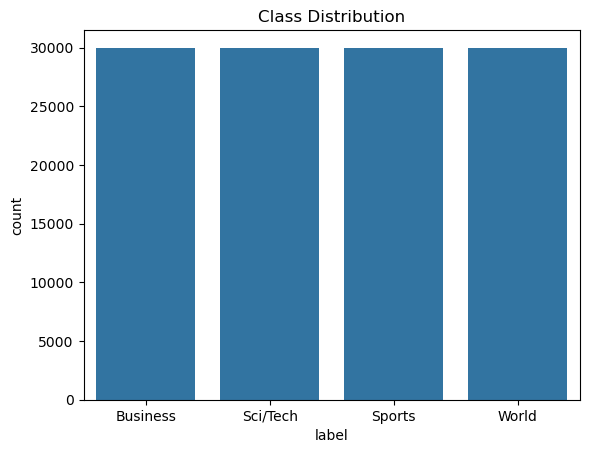

In [49]:
sns.countplot(x=df["label"].map(class_mapping))
plt.title("Class Distribution")
plt.show()